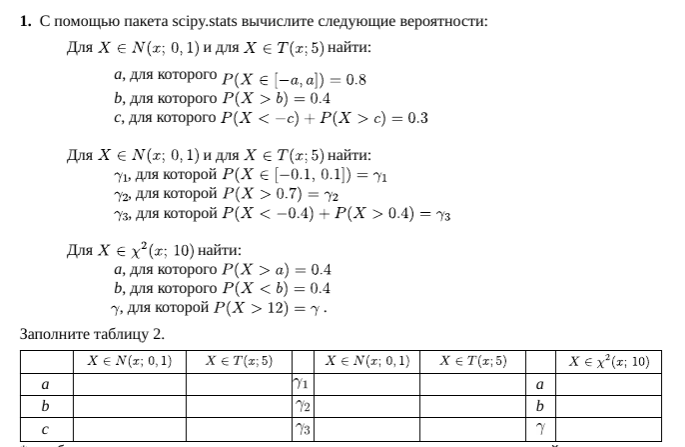

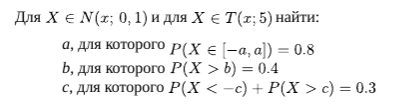

In [ ]:
from scipy import stats

norm_dist = stats.norm(0, 1)
student_dist = stats.t(df=5)
chi2_dist = stats.chi2(df=10)

# a: P(-a <= X <= a) = 0.8;
# F(a) = P(X <= a) = 0.8 + 0.1;
# F^-1(F(a)) = a
a_n, a_t = norm_dist.ppf(0.9), student_dist.ppf(0.9)


# b: P(X > b) = 0.4;
# b: F(b) = P(X <= b) = 0,6
# F^-1(F(b)) = b
b_n, b_t = norm_dist.ppf(0.6), student_dist.ppf(0.6)

# c: P(X < -c) + P(X > c) = 0.3;
# For symmetric about 0 distros N,T  f(x) = f(-x);
# p + p = 0.3
# p = 0.15
c_n, c_t = norm_dist.ppf(0.85), student_dist.ppf(0.85)

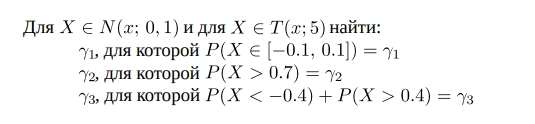

In [ ]:
gamma1_n = norm_dist.cdf(0.1) - norm_dist.cdf(-0.1)
gamma1_t = student_dist.cdf(0.1) - student_dist.cdf(-0.1)

gamma2_n = 1 - norm_dist.cdf(0.7)
gamma2_t = 1 - student_dist.cdf(0.7)

gamma3_n = 2 * norm_dist.cdf(-0.4)
gamma3_t = 2 * student_dist.cdf(-0.4)

np.float64(0.6891565167793516)

np.float64(0.6891565167793516)

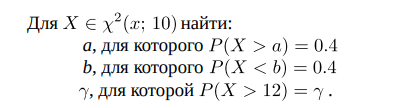

In [7]:
a_chi = chi2_dist.ppf(0.6)  # P(X > a) = 0.4
b_chi = chi2_dist.ppf(0.4)  # P(X < b) = 0.4
gamma_chi = 1 - chi2_dist.cdf(12)  # P(X > 12)

In [ ]:
import pandas as pd

df = pd.DataFrame(
    {
        "N(x;0,1)": [a_n, b_n, c_n],
        "T(x;5)": [a_t, b_t, c_t],
        " ": ["γ1", "γ2", "γ3"],
        "N2(x;0,1)": [gamma1_n, gamma2_n, gamma3_n],
        "T2(x;5)": [gamma1_t, gamma2_t, gamma3_t],
        "": ["a", "b", "γ"],
        "chi^2(x;10)": [a_chi, b_chi, gamma_chi],
    },
    index=["a", "b", "c"],
)

df

,"N(x;0,1)",T(x;5),,"N2(x;0,1)",T2(x;5),,chi^2(x;10)
a,1.281552,1.475884,γ1,0.079656,0.075770,a,10.473236
b,0.253347,0.267181,γ2,0.241964,0.257574,b,8.295472
c,1.036433,1.155767,γ3,0.689157,0.705673,γ,0.285057


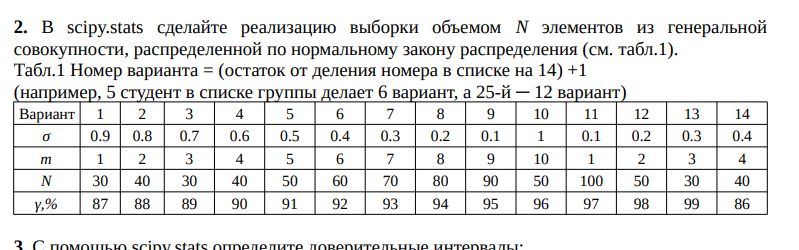

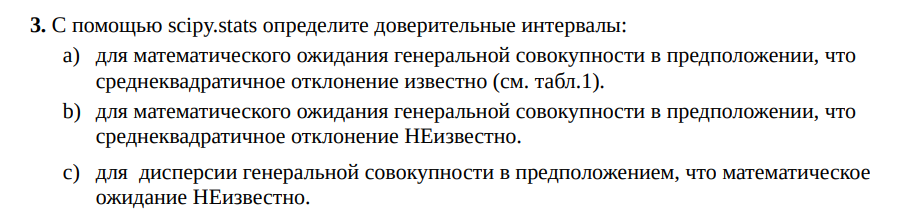

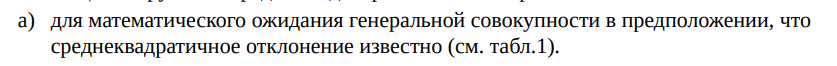

In [ ]:
from scipy import stats
import numpy as np

mu_true = 3  
sigma_known = 0.7  
n = 30  

np.random.seed(42)
sample = stats.norm(mu_true, sigma_known).rvs(n)

sample_mean = np.mean(sample)
print(f"Mean (x̄) = {sample_mean:.4f}")


gamma_confidence = 0.89

t = stats.norm.ppf((1 + gamma_confidence) / 2)
delta = t * sigma_known / np.sqrt(n)

print(f"Delta {delta}")
print(
    f"Confidence interval: [{sample_mean - delta:.4f}, {sample_mean + delta:.4f}], in which with probability {gamma_confidence} lies true mu {mu_true}"
)

Mean (x̄) = 2.8683
Delta 0.20425216793000553
Confidence interval: [2.6640, 3.0725], in which with probability 0.89 lies true mu 3


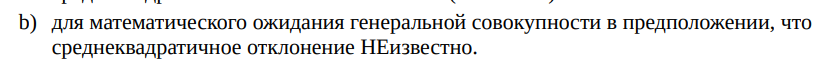

In [ ]:
from scipy import stats
import numpy as np

mu_true = 3
sigma_known = 0.7
n = 30

np.random.seed(42)
sample = stats.norm(mu_true, sigma_known).rvs(n)

sample_mean = np.mean(sample)
unb_sample_variance = np.sum((sample - sample_mean) ** 2) / (len(sample) - 1)
unb_sample_std = np.sqrt(unb_sample_variance)

print(f"Mean (x̄) = {sample_mean:.4f}")
print(f"Sample std (s) = {unb_sample_std:.4f}")

gamma_confidence = 0.89

t = stats.t.ppf((1 + gamma_confidence) / 2, df=n - 1)
delta = t * unb_sample_std / np.sqrt(n)

print(f"Delta {delta}")
print(
    f"Confidence interval: [{sample_mean - delta:.4f}, {sample_mean + delta:.4f}], "
    f"in which with probability {gamma_confidence} lies true mu {mu_true}"
)

Mean (x̄) = 2.8683
Sample std (s) = 0.6300
Delta 0.1896389176871392
Confidence interval: [2.6787, 3.0579], in which with probability 0.89 lies true mu 3


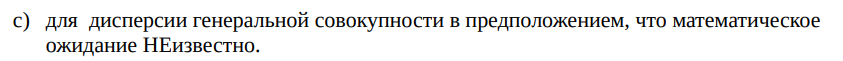

In [ ]:
from scipy import stats
import numpy as np

mu_true = 3
sigma_known = 0.7
n = 30

np.random.seed(42)
sample = stats.norm(mu_true, sigma_known).rvs(n)

unb_sample_variance = np.sum((sample - sample_mean) ** 2) / (len(sample) - 1)

print(f"Sample variance (S²) = {unb_sample_variance:.4f}")
print(f"True variance (σ²) = {sigma_known**2:.4f}")

gamma_confidence = 0.89
alpha = 1 - gamma_confidence


chi2_lower = stats.chi2.ppf(alpha / 2, df=n - 1) 
chi2_upper = stats.chi2.ppf(1 - alpha / 2, df=n - 1) 


lower_bound = (n - 1) * unb_sample_variance / chi2_upper
upper_bound = (n - 1) * unb_sample_variance / chi2_lower

print(f"Confidence interval for variance (σ²): [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"With probability {gamma_confidence} true variance lies in this interval")

print(
    f"Confidence interval for std (σ): [{np.sqrt(lower_bound):.4f}, {np.sqrt(upper_bound):.4f}]"
)

Sample variance (S²) = 0.3969
True variance (σ²) = 0.4900
Confidence interval for variance (σ²): [0.2734, 0.6407]
With probability 0.89 true variance lies in this interval
Confidence interval for std (σ): [0.5229, 0.8005]


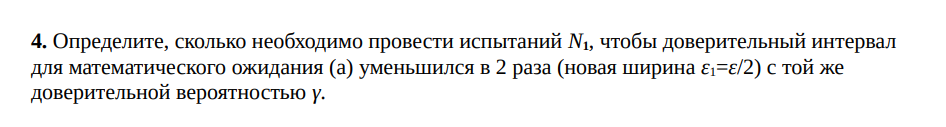

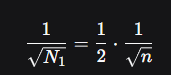
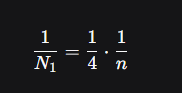
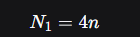

In [32]:
n = 30 
N1 = 4 * n
N1

120

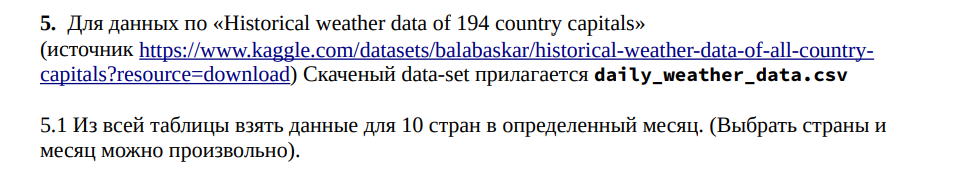

In [33]:
from io import TextIOWrapper
import zipfile
import pandas as pd

weather_zip = "daily_weather_data.zip"
with zipfile.ZipFile(weather_zip) as z:
    with z.open("daily_weather_data.csv") as f:
        weather_df = pd.read_csv(
            TextIOWrapper(f, encoding="latin-1"),
            sep=",",
            engine="python",
            header=0,
        )


weather_df["date"] = pd.to_datetime(weather_df["date"], format="%d-%m-%Y")
august_data = weather_df[weather_df["date"].dt.month == 8]
countries = weather_df["country"].drop_duplicates().head(10)

weather_df = august_data[august_data["country"].isin(countries)]

weather_df

,date,country,city,Latitude,Longitude,tavg,tmin,tmax,wdir,wspd,pres
11,2018-08-01,Abkhazia,Sukhumi,43.001525,41.023415,26.4,24.7,28.3,341.0,9.1,1008.5
12,2018-08-02,Abkhazia,Sukhumi,43.001525,41.023415,25.4,23.4,27.0,102.0,9.5,1008.7
13,2018-08-03,Abkhazia,Sukhumi,43.001525,41.023415,24.5,22.9,25.8,106.0,10.4,1007.9
14,2018-08-04,Abkhazia,Sukhumi,43.001525,41.023415,23.8,22.0,25.3,105.0,12.0,1008.8
15,2018-08-05,Abkhazia,Sukhumi,43.001525,41.023415,24.1,21.3,26.5,110.0,10.2,1012.4
...,...,...,...,...,...,...,...,...,...,...,...
17172,2022-08-27,Aruba,Oranjestad,12.509204,-70.008631,28.2,19.7,31.7,94.0,20.0,1010.5
17173,2022-08-28,Aruba,Oranjestad,12.509204,-70.008631,29.2,27.6,31.7,103.0,28.4,1011.3
17174,2022-08-29,Aruba,Oranjestad,12.509204,-70.008631,29.5,27.7,33.7,95.0,27.8,1012.6
17175,2022-08-30,Aruba,Oranjestad,12.509204,-70.008631,29.0,27.5,31.7,96.0,24.5,1012.5


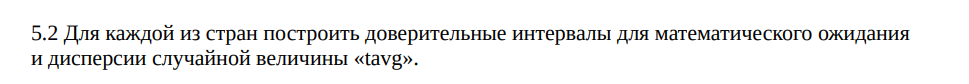

In [36]:
import math
alpha = 0.05
results = []

for country, group in weather_df.groupby("country"):
    current_country = group["tavg"].dropna()
    n = len(current_country)

    mean = current_country.mean()

    t = stats.t.ppf(1 - alpha / 2, df=n - 1)
    mean_level = t * current_country.std() / np.sqrt(n)
    mean_lower = mean - mean_level
    mean_upper = mean + mean_level

    var = current_country.var()

    chi_lower = stats.chi2.ppf(alpha / 2, df=n - 1)
    chi_upper = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
    var_lower = (n - 1) * var / chi_upper
    var_upper = (n - 1) * var / chi_lower
    results.append(
        {
            "country": country,
            "mean": round(mean, 3),
            "err": round(mean_level, 3),
            "mean_lower": round(mean_lower, 3),
            "mean_upper": round(mean_upper, 3),
            "var": round(var, 3),
            "var_lower": round(var_lower, 3),
            "var_upper": round(var_upper, 3),
        }
    )


result_df = pd.DataFrame(results)

result_df

,country,mean,err,mean_lower,mean_upper,var,var_lower,var_upper
0,Abkhazia,24.670,0.266,24.403,24.936,2.817,2.280,3.569
1,Aland Islands,16.525,0.408,16.116,16.933,6.613,5.353,8.380
2,Albania,26.448,0.325,26.123,26.773,4.195,3.395,5.315
3,Algeria,26.436,0.248,26.188,26.684,2.441,1.976,3.093
4,American Samoa,26.438,0.144,26.295,26.582,0.818,0.663,1.037
5,Angola,22.307,0.139,22.168,22.446,0.770,0.623,0.976
6,Anguilla,28.392,0.098,28.293,28.490,0.385,0.312,0.488
7,Antigua and Barbuda,28.155,0.085,28.070,28.241,0.289,0.234,0.367
8,Argentina,12.167,0.423,11.744,12.590,7.103,5.750,9.001
9,Aruba,28.900,0.085,28.815,28.985,0.286,0.232,0.363


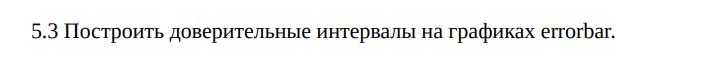

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.errorbar(
    x=result_df["country"],
    y=result_df["mean"],
    yerr=result_df["err"],
    fmt="o",
    capsize=7,
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Страна")
plt.ylabel("Средняя температура в августе, °C")
plt.grid(True, axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()